# Choosing between Graph and Functional APIs
LangGraph provides two different APIs to build agent workflows: the Graph API and the Functional API. Both APIs share the same underlying runtime and can be used together in the same application, but they are designed for different use cases and development preferences.

Use the Graph API when you need:
- Complex workflow visualization for debugging and documentation
- Explicit state management with shared data across multiple nodes
- Conditional branching with multiple decision points
- Parallel execution paths that need to merge later
- Team collaboration where visual representation aids understanding

Use the Functional API when you want:
- Minimal code changes to existing procedural code
- Standard control flow (if/else, loops, function calls)
- Function-scoped state without explicit state management
- Rapid prototyping with less boilerplate
- Linear workflows with simple branching logic

# Graph API Overview

## Graphs
LangGraph models agent workflows as graphs. You define the behavior of your agents using three key components:

1. `State`: A shared data structure that represents the current snapshot of your application. It can be any data type, but is typically defined using a shared state schema.
2. `Nodes`: Functions that encode the logic of your agents. They receive the current state as input, perform some computation or side-effect, and return an updated state.
3. `Edges`: Functions that determine which Node to execute next based on the current state. They can be conditional branches or fixed transitions.

By composing `Nodes` and `Edges`, you can create complex, looping workflows that evolve the state over time. The real power, though, comes from how LangGraph manages that state.

To emphasize: Nodes and Edges are nothing more than functions—they can contain an LLM or just good ol’ (Good old) code.

<b>In short:</b> nodes do the work, edges tell what to do next.

LangGraph’s underlying graph algorithm uses message passing to define a general program. When a Node completes its operation, it sends messages along one or more edges to other node(s). These recipient nodes then execute their functions, pass the resulting messages to the next set of nodes, and the process continues.

A super-step can be considered a single iteration over the graph nodes. Nodes that run in parallel are part of the same super-step, while nodes that run sequentially belong to separate super-steps. At the start of graph execution, all nodes begin in an inactive state. A node becomes active when it receives a new message (state) on any of its incoming edges (or “channels”). The active node then runs its function and responds with updates. At the end of each super-step, nodes with no incoming messages vote to halt by marking themselves as inactive. The graph execution terminates when all nodes are inactive and no messages are in transit.

## StateGraph

The StateGraph class is the main graph class to use. This is parameterized by a user defined `State` object.

### Compiling your graph

To build your graph, you first define the `state`, you then add `nodes` and `edges`, and then you compile it. What exactly is compiling your graph and why is it needed?

Compiling is a pretty simple step. It provides a few basic checks on the structure of your graph (no orphaned nodes, etc). It is also where you can specify runtime args like `checkpointers` and `breakpoints`. You compile your graph by just calling the `.compile` method:

##### `graph = graph_builder.compile(...)`

### State

The first thing you do when you define a graph is define the `State` of the graph. The `State` consists of the <b>schema of the graph</b> as well as <b>reducer functions</b> which specify how to apply updates to the state. The `schema` of the State will be the input schema to all `Nodes and Edges` in the graph, and can be either a `TypedDict or a Pydantic` model. All Nodes will emit updates to the State which are then applied using the specified reducer function.

### Schema

The main documented way to specify the schema of a graph is by using a `TypedDict`. If you want to provide default values in your state, use a `dataclass`. We also support using a Pydantic `BaseModel` as your graph state if you want recursive data validation (though note that Pydantic is less performant than a `TypedDict or dataclass`).
By default, the graph will have the same input and output schemas. If you want to change this, you can also specify explicit input and output schemas directly. This is useful when you have a lot of keys, and some are explicitly for input and others for output. See the guide for more information.

### Multiple Schema
Typically, all graph nodes communicate with a single schema. This means that they will read and write to the same state channels. But, there are cases where we want more control over this:

* Internal nodes can pass information that is not required in the graph’s input / output.
* We may also want to use different input / output schemas for the graph. The output might, for example, only contain a single relevant output key.

It is possible to have nodes write to private state channels inside the graph for internal node communication. We can simply define a private schema, `PrivateState`.

It is also possible to define explicit input and output schemas for a graph. In these cases, we define an “internal” schema that contains all keys relevant to graph operations. But, we also define `input` and `output` schemas that are sub-sets of the “internal” schema to constrain the input and output of the graph. See Define input and output schemas for more detail.

# Example1 : Sequential Workflow 

In [5]:
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
#State: Define the State of the graph.

from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str


In [8]:
#Nodes: Nodes are just python functions.
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}

In [9]:
#Edges:Edges connect the nodes.
from websockets.sync.client import connect
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# Add
graph = builder.compile()



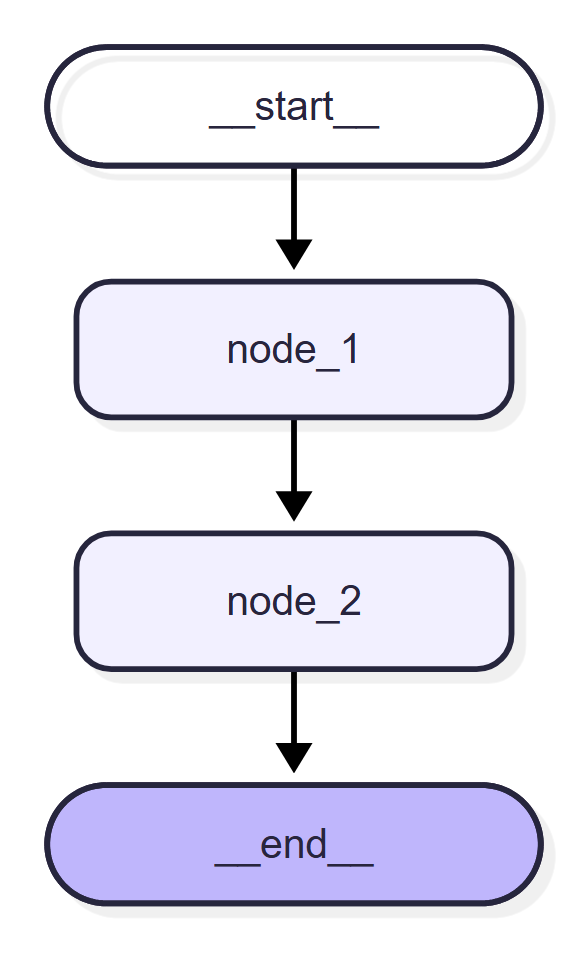

In [10]:
import langchain_core.runnables.graph_mermaid as graph_mermaid
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod
import nest_asyncio2

from pyppeteer import launch
nest_asyncio2.apply()
graph_mermaid.launch = lambda: launch(
    executablePath=r"C:\Program Files\Google\Chrome\Application\chrome.exe"
 )
graph_mermaid._HAS_PYPPETEER = True

# View
display(Image(graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.PYPPETEER
)))

In [18]:
graph.invoke({"graph_state": "Hi, This is Rahul."})

---Node 1---
---Node 2---


{'graph_state': 'Hi, This is Rahul. I am happy!'}

# 2. Conditional Workflow : add_conditional_edges

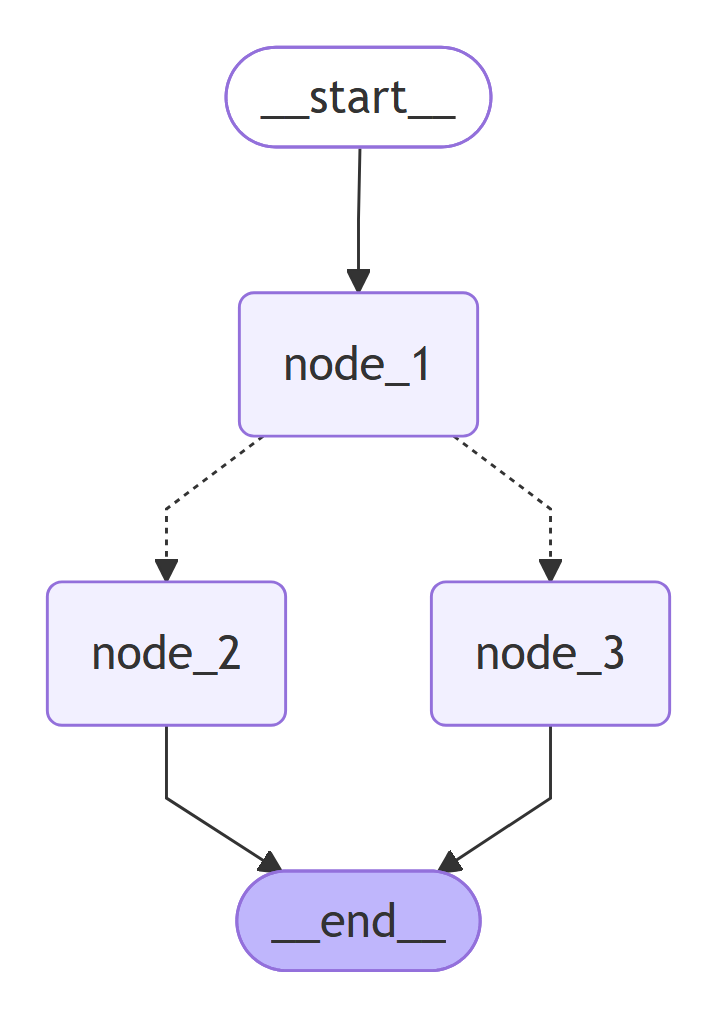

In [19]:
#Conditional Edges are used if you want to optionally route between nodes. 
# Conditional edges are implemented as functions that return the next node to visit based on some logic.

import random
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:
    
    # Often, we will use state to decide on the next node to visit
    user_input = state['graph_state'] 
    
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2"
    
    # 50% of the time, we return Node 3
    return "node_3"

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

#Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.PYPPETEER
)))

# Conditional Edges are showing in dot line whereas regular edges are shown in solid line.

# Conditional Edges are showing in dot line whereas regular edges are shown in solid line.

In [22]:
#Graph Invocation
#invoke is one of the standard methods in this interface. This provides a standard way to execute LangChain components.
graph.invoke({"graph_state": "Hi, This is Rahul."})



---Node 1---
---Node 2---


{'graph_state': 'Hi, This is Rahul. I am happy!'}

`invoke` runs the entire graph synchronously. This waits for each step to complete before moving to the next.
It returns the final state of the graph after all nodes have executed.

# Example3: Build a Two-Stage Decision Flow

In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import Literal

class ServiceState(TypedDict):
    query: str
    category: str
    sentiment: str
    response: str
    escalated: bool

def classify_query(state: ServiceState) -> dict:
    query = state["query"].lower()
    if "refund" in query or "money" in query:
        category = "billing"
    elif "broken" in query or "error" in query or "bug" in query:
        category = "technical"
    else:
        category = "general"

    sentiment = "negative" if any(
        w in query for w in ["angry", "terrible", "worst"]
    ) else "neutral"
    return {"category": category, "sentiment": sentiment}

def handle_billing(state: ServiceState) -> dict:
    return {"response": "Node handle_billing: Billing concern flagged. Expect resolution within 24 hours."}

def handle_technical(state: ServiceState) -> dict:
    return {"response": "Node handle_technical: Let me troubleshoot that. Have you tried restarting the application?"}

def handle_general(state: ServiceState) -> dict:
    return {"response": "Node handle_general: Thanks for reaching out! Connecting you with the right team."}

def escalate_to_human(state: ServiceState) -> dict:
    return {"response": "Node escalate_to_human: Escalating to a human agent due to negative sentiment.", "escalated": True}

def finalize(state: ServiceState) -> dict:
    return {}  # no-op: response already set by handler

def route_by_category(state: ServiceState) -> Literal["handle_billing", "handle_technical", "handle_general"]:
    category = state["category"]
    if category == "billing":
        return "handle_billing"
    elif category == "technical":
        return "handle_technical"
    else:
        return "handle_general"

def route_by_sentiment(state: ServiceState) -> Literal["escalate_to_human", "finalize"]:
    if state["sentiment"] == "negative":
        return "escalate_to_human"
    return "finalize"

graph = StateGraph(ServiceState)
graph.add_node("classify_query", classify_query)
graph.add_node("handle_billing", handle_billing)
graph.add_node("handle_technical", handle_technical)
graph.add_node("handle_general", handle_general)
graph.add_node("escalate_to_human", escalate_to_human)
graph.add_node("finalize", finalize)

graph.add_edge(START, "classify_query")
graph.add_conditional_edges("classify_query", route_by_category)
graph.add_conditional_edges("handle_billing", route_by_sentiment)
graph.add_conditional_edges("handle_technical", route_by_sentiment)
graph.add_conditional_edges("handle_general", route_by_sentiment)
graph.add_edge("escalate_to_human", END)
graph.add_edge("finalize", END)

app = graph.compile()

queries = [
    "I need a refund for my subscription",
    "The app is broken and I'm angry about it",
    "What are your business hours?",
]

for query in queries:
    result = app.invoke({
        "query": query, "category": "", "sentiment": "",
        "response": "", "escalated": False,
    })
    print(f"Query: {query}")
    print(f"  Category: {result['category']} | Sentiment: {result['sentiment']}")
    print(f"  Response: {result['response']}")
    print(f"  Escalated: {result['escalated']}\n")


Query: I need a refund for my subscription
  Category: billing | Sentiment: neutral
  Response: Node handle_billing: Billing concern flagged. Expect resolution within 24 hours.
  Escalated: False

Query: The app is broken and I'm angry about it
  Category: technical | Sentiment: negative
  Response: Node escalate_to_human: Escalating to a human agent due to negative sentiment.
  Escalated: True

Query: What are your business hours?
  Category: general | Sentiment: neutral
  Response: Node handle_general: Thanks for reaching out! Connecting you with the right team.
  Escalated: False



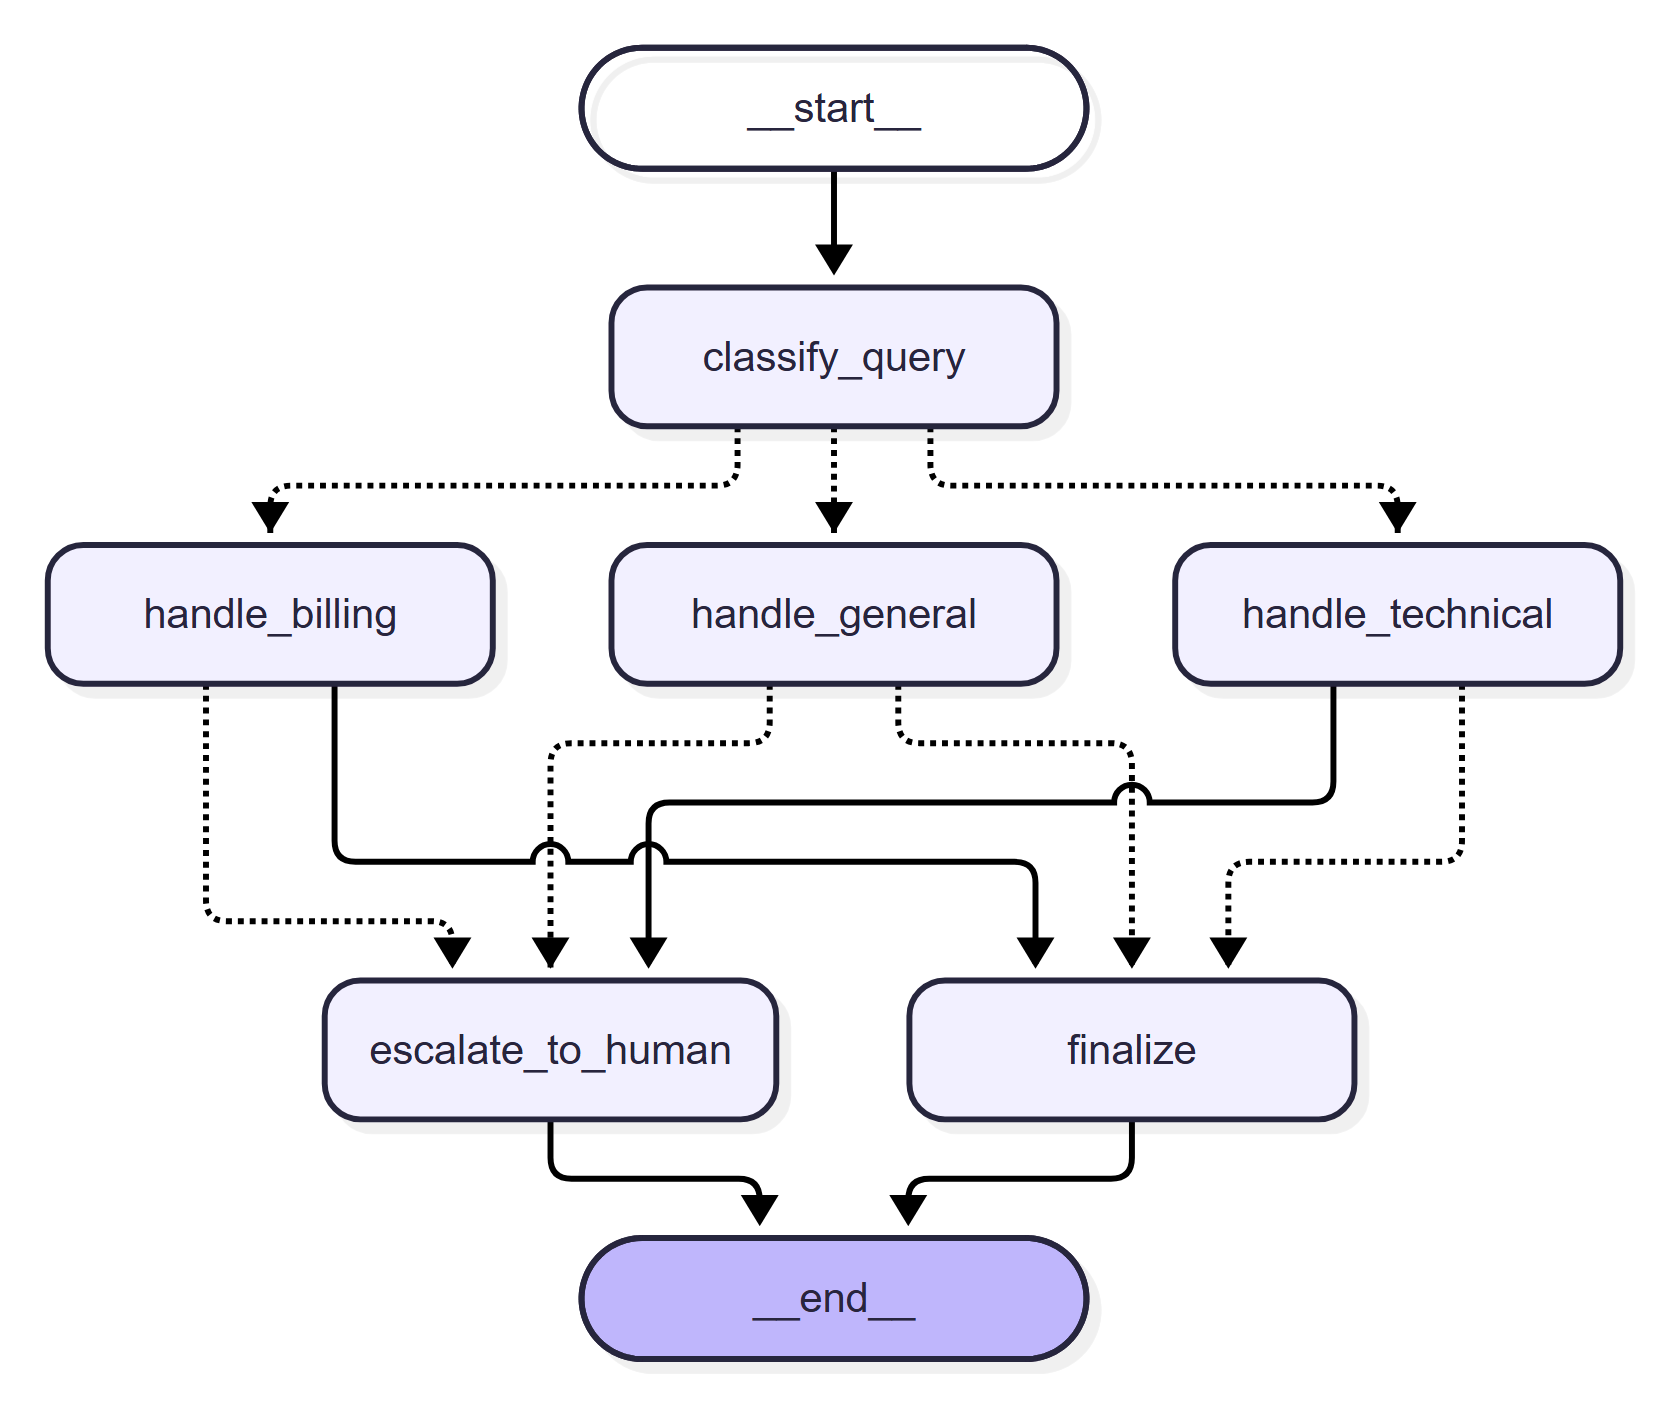

In [11]:
# View
display(Image(app.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.PYPPETEER
)))

In [3]:
print(app.get_graph().draw_ascii())

                                +-----------+                                   
                                | __start__ |                                   
                                +-----------+                                   
                                      *                                         
                                      *                                         
                                      *                                         
                              +----------------+                                
                              | classify_query |                                
                           ...+----------------+...                             
                      .....           .            .....                        
                 .....                .                 .....                   
              ...                     .                      ...                
+----------------+          

#### Summary
Conditional edges turn LangGraph from a fixed pipe into a choice-making engine. Here’s what you picked up:

* **Static edges** lock nodes in a set order. Conditional edges swap them for runtime picks.
* `add_conditional_edges()` takes a source node, a routing function, and an optional path map.
* **Routing functions** are pure logic — they read state and hand back a string. Never change state inside one.
* **LLM-based routing** works the same way. Always clean model text and add a fallback.
* **Parallel branching** sends state to many nodes by having the router hand back a list.
* **Fallback paths** are a must. Every router needs an `else`.
* **Debugging** uses `draw_ascii()`, print calls in routers, and `stream()` mode.

#### Q. Can I wire many conditional edges out of one node?
No. A node gets at most one outgoing conditional edge. If you need to check many fields, fold them into a single routing function with nested if/elif checks.

#### Q. How is add_conditional_edges() different from Command?
add_conditional_edges() locks in routing when you build the graph. Command (a newer feature) lets nodes choose their next stop at runtime by sending back a Command with a goto field. For everyday routing, conditional edges are the simpler choice. We’ll explore Command in a later post.

# 2 Ways we can create State Schemas
    1. Typedict
    2. Pydantic 

In [ ]:
from typing import TypedDict
from pydantic import BaseModel
from dataclasses import dataclass

# Option 1: TypedDict (most common -- no runtime overhead)
class StateA(TypedDict):
    value: str

# Option 2: Pydantic (adds runtime validation)
class StateB(BaseModel):
    value: str

# Option 3: Dataclass (mutable by default)
@dataclass
class StateC:
    value: str

print("All three work as state schemas in LangGraph")

All three work as state schemas in LangGraph


#### Q. Can I use Pydantic instead of TypedDict for state?
Yes. LangGraph works with both TypedDict and Pydantic BaseModel. Pydantic adds checks at runtime — if a node returns bad data, you get a clear error right away. For basic graphs, TypedDict does the job. For production apps where you want strict data rules, Pydantic is a solid pick.

#### Q. What happens when two nodes write to the same state field?
The last node wins. Say node_a sets {"count": 5} and then node_b sets {"count": 10}. The final state has count: 10. If you want to stack values up instead of replacing them, LangGraph has reducer functions.

#### Q. How many nodes can a graph hold?
There’s no hard cap. Graphs with 30+ nodes run fine in production. But once you pass 10-15 nodes, think about splitting into subgraphs. They’re easier to test and maintain. I cover subgraphs later in this learning path.

#### Q. Is the run order always the same?
For straight chains (A -> B -> C), yes. For conditional edges, the path depends on state at runtime. But the routing function always gives the same answer for the same input. LangGraph adds no randomness to the order.

#### Q. Why TypedDict for State Schemas?
You might wonder why TypedDict and not a plain dict or a Pydantic model. The short answer: it gives you the best balance of safety and speed.
A plain dict offers no type safety at all. A Pydantic model brings runtime checks you often don’t need. TypedDict sits in the middle — your IDE and type checker can catch errors, but there’s no extra cost at runtime.

# Example2 : Multiple schemas

Typically, all graph nodes communicate with a single schema. This means that they will read and write to the same state channels. But, there are cases where we want more control over this:

* Internal nodes can pass information that is not required in the graph’s input / output.
* We may also want to use different input / output schemas for the graph. The output might, for example, only contain a single relevant output key.

It is possible to have nodes write to private state channels inside the graph for internal node communication. We can simply define a private schema, `PrivateState`.

It is also possible to define explicit input and output schemas for a graph. In these cases, we define an “internal” schema that contains all keys relevant to graph operations. But, we also define `input` and `output` schemas that are sub-sets of the “internal” schema to constrain the input and output of the graph. See Define input and output schemas for more detail.

In [28]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class InputState(TypedDict):
    user_input: str

class OutputState(TypedDict):
    graph_output: str

class OverallState(TypedDict):
    foo: str
    user_state: InputState
    graph_state: OutputState

class PrivateState(TypedDict):
    bar: str


In [32]:
def node_1(state: InputState) -> OverallState:
    # Write to OverallState
    return {"foo": state["user_input"] + " name"}


def node_2(state: OverallState) -> PrivateState:
    # Read from OverallState, write to PrivateState
    return {"bar": state["foo"] + " is"}


def node_3(state: PrivateState) -> OutputState:
    # Read from PrivateState, write to OutputState
    return {"graph_output": state["bar"] + " Rahul"}

In [33]:
builder = StateGraph(OverallState, input_schema=InputState, output_schema=OutputState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

graph = builder.compile()
graph.invoke({"user_input": "My"})


{'graph_output': 'My name is Rahul'}

There are two subtle and important points to note here:

1. We pass `state: InputState` as the input schema to `node_1`. But, we write out to `foo`, a channel in `OverallState`. How can we write out to a state channel that is not included in the input schema? This is because a node can <b>write to any state channel in the graph state.</b> The graph state is the union of the state channels defined at initialization, which includes `OverallState` and the filters `InputState` and `OutputState`.

2. We initialize the graph with:

        ```
        StateGraph(
            OverallState,
            input_schema=InputState,
            output_schema=OutputState
        )
        ```

Q. How can we write to `PrivateState` in `node_2`? How does the graph gain access to this schema if it was not passed in the `StateGraph` initialization?

We can do this because `_nodes` can also declare additional state `channels_` as long as the state schema definition exists. In this case, the `PrivateState` schema is defined, so we can add `bar` as a new state channel in the graph and write to it.

### Private channels are not redacted when streaming.

Input, output, and private schemas constrain what each node reads (its input schema) and what `invoke` returns (the output schema). They do not hide channels from `stream`.

When you stream with `stream_mode="values"`, the graph emits all of its state channels by default, including private ones, because values streaming defaults to the full set of state channels rather than the output schema. This is why a private channel like `bar` is hidden by `invoke` but visible while streaming:

In [34]:
stream = graph.stream_events({"user_input": "My"}, version="v3")
for snapshot in stream.values:
    print(snapshot)

{'user_input': 'My'}
{'foo': 'My name', 'user_input': 'My'}
{'foo': 'My name', 'user_input': 'My', 'bar': 'My name is'}
{'foo': 'My name', 'user_input': 'My', 'graph_output': 'My name is Rahul', 'bar': 'My name is'}


d:\Project_Code\Langgraph\lc-academy-env\Lib\site-packages\langgraph\pregel\main.py:3708: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
d:\Project_Code\Langgraph\lc-academy-env\Lib\site-packages\langgraph\pregel\main.py:3558: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)


In [36]:
stream = graph.stream_events(
    {"user_input": "My"},
    version="v3",
    output_keys=["graph_output"],
)
for snapshot in stream.values:
    print(snapshot)
# {'graph_output': 'My name is Rahul'}

{'graph_output': 'My name is Rahul'}


# Reducer

# The Default Behavior: Overwrite
If you don’t set a reducer, LangGraph just overwrites the old value with the new one.

In [83]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class CounterState(TypedDict):
    count: int
    label: str

def node_a(state: CounterState) -> dict:
    return {"count": 15, "label": "from A"}

def node_b(state: CounterState) -> dict:
    return {"count": 10}  # Only updates count, not label

graph = StateGraph(CounterState)
graph.add_node("a", node_a)
graph.add_node("b", node_b)
graph.add_edge(START, "a")
graph.add_edge("a", "b")
graph.add_edge("b", END)

app = graph.compile()
result = app.invoke({"count": 0, "label": ""})
print(f"count: {result['count']}")
print(f"label: {result['label']}")


count: 10
label: from A


# What Are Reducers and Why Do They Matter?
A reducer tells LangGraph how to blend the old value with a new value, rather than just replacing it. The idea comes from functional programming — a reducer takes two inputs (the current value and the new update) and returns the merged result.

In [ ]:
# Syntax

from typing import Annotated, TypedDict
import operator

class AgentState(TypedDict):
    messages: Annotated[list, operator.add]  # Concatenate lists
    count: int                                # Overwrite (no reducer)

print("messages uses operator.add reducer")
print("count uses default overwrite")



messages uses operator.add reducer
count uses default overwrite


That Annotated[list, operator.add] tells LangGraph: “When a node sends a new list for messages,join it to the end of what’s already there."

In [86]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
import operator

class ListState(TypedDict):
    items: Annotated[list, operator.add]

def add_fruits(state: ListState) -> dict:
    return {"items": ["apple", "banana"]}

def add_veggies(state: ListState) -> dict:
    return {"items": ["carrot", "spinach"]}

graph = StateGraph(ListState)
graph.add_node("fruits", add_fruits)
graph.add_node("veggies", add_veggies)
graph.add_edge(START, "fruits")
graph.add_edge("fruits", "veggies")
graph.add_edge("veggies", END)

app = graph.compile()
result = app.invoke({"items": []})
print(result)


{'items': ['apple', 'banana', 'carrot', 'spinach']}


Without the reducer, only ["carrot", "spinach"] would be left. With operator.add, both lists get joined. That’s the whole point — reducers let you control how LangGraph state management works across nodes.

# The `add_messages` Reducer — Your Go-To for Chat Workflows
If you’re building a chatbot or agent, you need a message list that grows as the chat goes on. LangGraph ships with a built-in reducer called `add_messages` for exactly this.

Why not just use operator.add? Because add_messages does something extra. It checks message IDs. If you send a message with the same ID as one already in the list, it swaps in the new one instead of making a copy.

In [87]:
from typing import Annotated, TypedDict
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# Simulating what happens across nodes
existing = [HumanMessage(content="Hello", id="msg-1")]
update = [AIMessage(content="Hi there!", id="msg-2")]

result = add_messages(existing, update)
print(f"Message count: {len(result)}")
for msg in result:
    print(f"  {msg.__class__.__name__}: {msg.content}")


Message count: 2
  HumanMessage: Hello
  AIMessage: Hi there!


# `MessagesState` — The Shortcut You’ll Reach For
Writing messages: `Annotated[list[AnyMessage], add_messages]` in every state class gets old fast. LangGraph gives you MessagesState — a ready-made class with that field already set up

In [89]:
from langgraph.graph import MessagesState

# MessagesState already has:
#   messages: Annotated[list[AnyMessage], add_messages]

# Extend it with your own fields
class MyAgentState(MessagesState):
    current_tool: str
    iteration: int

print(f"Inherited keys: {list(MessagesState.__annotations__.keys())}")
print(f"MyAgentState keys: {list(MyAgentState.__annotations__.keys())}")


Inherited keys: ['messages']
MyAgentState keys: ['messages', 'current_tool', 'iteration']


In [90]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import HumanMessage, AIMessage

class AgentState(MessagesState):
    tool_called: bool

def chatbot(state: AgentState) -> dict:
    last_msg = state["messages"][-1]
    reply = f"You said: {last_msg.content}"
    return {
        "messages": [AIMessage(content=reply)],
        "tool_called": False,
    }

graph = StateGraph(AgentState)
graph.add_node("chatbot", chatbot)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

app = graph.compile()
result = app.invoke({
    "messages": [HumanMessage(content="How does state work?")],
    "tool_called": False,
})

for msg in result["messages"]:
    print(f"{msg.__class__.__name__}: {msg.content}")
print(f"Tool called: {result['tool_called']}")


HumanMessage: How does state work?
AIMessage: You said: How does state work?
Tool called: False


# Writing Custom Reducer Functions
Now and then, `operator.add` and `add_messages` won’t fit your needs. Maybe you want to keep only the last N items, merge dicts, or add your own logic.

A custom reducer is simply a function with this shape: (current_value, new_value) -> merged_value. Here’s one that acts like a sliding window, keeping only the 3 most recent entries:

In [ ]:
from typing import Annotated, TypedDict

def keep_last_3(current: list, new: list) -> list:
    """Append new items but keep only the last 3."""
    combined = current + new
    return combined[-3:]

class BoundedState(TypedDict):
    recent_actions: Annotated[list, keep_last_3]

# Simulating sequential updates
step_0 = ["search", "read"]
step_1 = keep_last_3(step_0, ["write"])
print(f"After update 1: {step_1}")

step_2 = keep_last_3(step_1, ["deploy"])
print(f"After update 2: {step_2}")



After update 1: ['search', 'read', 'write']
After update 2: ['read', 'write', 'deploy']


In [92]:
#Here’s one more real-world case — a dict merger that keeps keys from earlier nodes:

from typing import Annotated, TypedDict

def merge_dicts(current: dict, new: dict) -> dict:
    """Shallow merge: new values overwrite existing keys."""
    return {**current, **new}

class MetadataState(TypedDict):
    metadata: Annotated[dict, merge_dicts]

existing = {"source": "api", "confidence": 0.8}
update = {"timestamp": "2026-03-10", "confidence": 0.95}

result = merge_dicts(existing, update)
print(result)


{'source': 'api', 'confidence': 0.95, 'timestamp': '2026-03-10'}


Notice that source from Node A survived. The confidence field took Node B’s fresher value. And timestamp is a new key entirely. Without this merger, plain overwrite would have thrown out the whole dict and started over.

# Debugging State: Seeing What Each Node Did
When your graph gives you odd results, you need to see what each node kicked in. The stream method from LangGraph shows you step by step.

In [93]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
import operator

class DebugState(TypedDict):
    log: Annotated[list[str], operator.add]
    value: int

def step_one(state: DebugState) -> dict:
    return {"log": ["step_one ran"], "value": 10}

def step_two(state: DebugState) -> dict:
    doubled = state["value"] * 2
    return {"log": [f"step_two doubled to {doubled}"], "value": doubled}

graph = StateGraph(DebugState)
graph.add_node("step_one", step_one)
graph.add_node("step_two", step_two)
graph.add_edge(START, "step_one")
graph.add_edge("step_one", "step_two")
graph.add_edge("step_two", END)

app = graph.compile()

for event in app.stream({"log": [], "value": 0}):
    print(event)
    print("---")


{'step_one': {'log': ['step_one ran'], 'value': 10}}
---
{'step_two': {'log': ['step_two doubled to 20'], 'value': 20}}
---


# Common Operator 
```
from operator import (
    add,
    or_,
    and_,
    mul,
    concat
)
```
* add      # list merge, string concat, numeric sum
* or_      # dict merge, set union
* and_     # set intersection
* mul      # multiplication
* concat   # sequence concatenation


Custom reducers you'll commonly write:

* latest_value()
* first_value()
* max_reducer()
* min_reducer()
* dedup_reducer()
* dict_merge()

For 90% of LangGraph applications, you'll primarily use:
*  Annotated[list, add]
* Annotated[dict, or_]

# Common Mistakes with LangGraph State

### Mistake 1: Changing State in Place
This is the top bug. You reach into state and edit it right there.

```
# WRONG -- mutating state directly
def bad_node(state):
    state["messages"].append("new message")  # Direct mutation!
    return state

# CORRECT -- return only the updates
def good_node(state):
    return {"messages": ["new message"]}  # Let the reducer handle it

```

Editing state in place skips the reducer. It might pass simple tests, but it’ll cause sneaky bugs with checkpoints, parallel nodes, and state replay.

### Mistake 2: No Reducer for Parallel Nodes
Two nodes running at the same time both write to the same key? You must add a reducer. Without one, LangGraph can’t sort out the clash.

```
from typing import Annotated, TypedDict
import operator

# WRONG -- will crash with InvalidUpdateError in parallel
class BadState(TypedDict):
    results: list

# CORRECT -- reducer handles parallel writes
class GoodState(TypedDict):
    results: Annotated[list, operator.add]

```

### Mistake 3: Sending Back the Whole State
Nodes should only return what changed. Sending back everything causes needless overwrites and breaks your reducers.

```
# WRONG -- returning the full state
def bad_node(state):
    state_copy = dict(state)
    state_copy["status"] = "done"
    return state_copy  # Overwrites ALL keys, even with reducers

# CORRECT -- return only what changed
def good_node(state):
    return {"status": "done"}
```

### Mistake 4: Mixing Up operator.add Across Types
`operator.add` behaves differently for each type. Make sure it does what you expect.
```
from typing import Annotated, TypedDict
import operator

class ConfusingState(TypedDict):
    count: Annotated[int, operator.add]    # 5 + 3 = 8 (numeric)
    items: Annotated[list, operator.add]   # [1] + [2] = [1, 2] (concat)
    label: Annotated[str, operator.add]    # "hi" + "!" = "hi!" (concat)

print("int: adds numerically")
print("list: concatenates")
print("str: concatenates characters")
```



#### Q. When Does Your State Schema Choice Matter Less?
Not every graph calls for a fancy state schema. For simple chains with 2–3 nodes and no parallel work, a basic `TypedDict` with no reducers does the job. Don’t over-build the state for a graph that won’t use it.

Reducers start to matter when you have:

* **Parallel nodes** writing to the same key
* **Message history** that must grow, not get replaced
* **Multi-step flows** where each node adds to a growing list
* **Cyclic graphs** where a node runs many times and each run should add to the pile, not wipe it clean

If your graph is straight-line with no shared lists, plain overwrite is simpler and easier to follow.

#### Q. Can I use Pydantic instead of TypedDict for state?
Absolutely. LangGraph accepts `BaseModel` and dataclasses in addition to `TypedDict`. Pydantic gives you runtime type checks — so if a node sends bad data, you see an error at once. The downside is a slight speed cost.

#### Q. What happens if I don’t set a starting value for a state field?
You’ll get a `KeyError` when a node tries to read it. Always pass every field when you call `invoke()` or `stream()`.

#### Q. Can reducers see the full state?
No. A reducer only gets the current value and the new value for its own field. If you need cross-field logic, put it in a node function.

#### Q.How do I remove items from a list that uses operator.add?
You can’t — `operator.add` only grows the list. Write a custom reducer that supports removal, or use `add_messages` with `RemoveMessage` if you’re working with messages.

#### Q.Does state carry over between graph runs?
Not by default. Each call to `invoke()` starts fresh. To save state across runs, you’ll need a checkpointer — we’ll cover that in a later post on persistence.

# Messages

Chat models can use `messages`, which capture different roles within a conversation.

LangChain supports various message types, including `HumanMessage, AIMessage, SystemMessage, and ToolMessage`.

These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Each message can be supplied with a few things:

* `content` - content of the message
* `name` - optionally, a message author
* `response_metadata` - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)

In [62]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage

messages = [SystemMessage(content="You are a helpful travel assistant. Answer briefly.", name="System"),
            HumanMessage(content="What is the capital of France?", name="Rahul"),
            AIMessage(content="The capital of France is Paris.", name="Model"),
            ToolMessage(content="Current temperature in Paris: 22°C",tool_call_id="call_123", name="WeatherTool")]



for m in messages:
    m.pretty_print()

================================ System Message ================================
Name: System

You are a helpful travel assistant. Answer briefly.
================================ Human Message =================================
Name: Rahul

What is the capital of France?
================================== Ai Message ==================================
Name: Model

The capital of France is Paris.
================================= Tool Message =================================
Name: WeatherTool

Current temperature in Paris: 22°C


# Chat Models

In [ ]:
# from langchain_openai import ChatOpenAI
# llm = ChatOpenAI(model="gpt-4o")
# result = llm.invoke(messages)
# type(result)

# Note I am using Corporate Chat OpenAI gpt-4o model 

import warnings
warnings.filterwarnings("ignore")
from corporate_model.organization_LLM import CorporateChatModel
model = CorporateChatModel()
response = model.invoke("What is the color of the sky? Answer in 1 word.")
print(response.content)

Blue


In [57]:
messages = [SystemMessage(content="You are a helpful travel assistant. Answer briefly.", name="System"),
            HumanMessage(content="What is the capital of France?", name="Rahul"),
            ]

result = model.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [58]:
result

AIMessage(content='Paris.', additional_kwargs={}, response_metadata={}, id='lc_run--01a06cef-ca4c-7a22-ab6f-f03ed26dcc81-0', tool_calls=[], invalid_tool_calls=[])

In [59]:
result.content

'Paris.'

In [61]:
result.response_metadata

{}

# Tools : Tool Calling 

Tools are useful whenever you want a model to interact with external systems.
External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language.

At its core, tool calling is a way for the LLM to ask your code to run a specific function. The model does not run anything itself — it sends a structured message that says “please call this function with these inputs.” Your code then runs the function and passes the result back.

In LangGraph, three pieces work together to make this happen. First, you create tools with LangChain’s `@tool` decorator. Second, you link those tools to your chat model using `.bind_tools()`. Third, you use `ToolNode` from `langgraph.prebuilt` to run the tools when the LLM asks for them.

In [20]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()

# Step 1: Define a tool
@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers together."""
    return a * b

# Step 2: Bind the tool to the model
tools = [multiply]
#llm = ChatOpenAI(model="gpt-4o-mini").bind_tools(tools)

print(multiply.name)         # 'multiply'
print(multiply.description)  # 'Multiply two numbers together.'
print(multiply.args) 
result = multiply.invoke({"a": 3, "b": 4})
print(result) 

print("Setup complete — model with tool binding ready")


multiply
Multiply two numbers together.
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}
12
Setup complete — model with tool binding ready


Three lines of setup is all it takes. The `@tool `decorator wraps a plain function so the LLM can find and call it. The `.bind_tools()` method tells the model what tools are on offer, what inputs they expect, and what they do. LangGraph handles everything from there.

Every tool starts as a normal Python function. The `@tool` decorator from `langchain_core.tools` turns it into something the LLM can discover. Two things matter most: the function name and the docstring.

### bind_tools Connect Tools to the Model?
Creating tools is just the first step. The LLM still doesn’t know they exist. That’s where `.bind_tools()` comes in — it attaches the tool schemas to every call so the model can see what’s on the table.

```
tools = [multiply, search_web, get_weather]
llm_with_tools = ChatOpenAI(model="gpt-4o-mini").bind_tools(tools)

# Ask something that should trigger tool use
response = llm_with_tools.invoke(
    [HumanMessage(content="What is 15 times 23?")]
)

print(f"Content: '{response.content}'")
print(f"Tool calls: {response.tool_calls}")
```


Graph compiled with agent and tool nodes


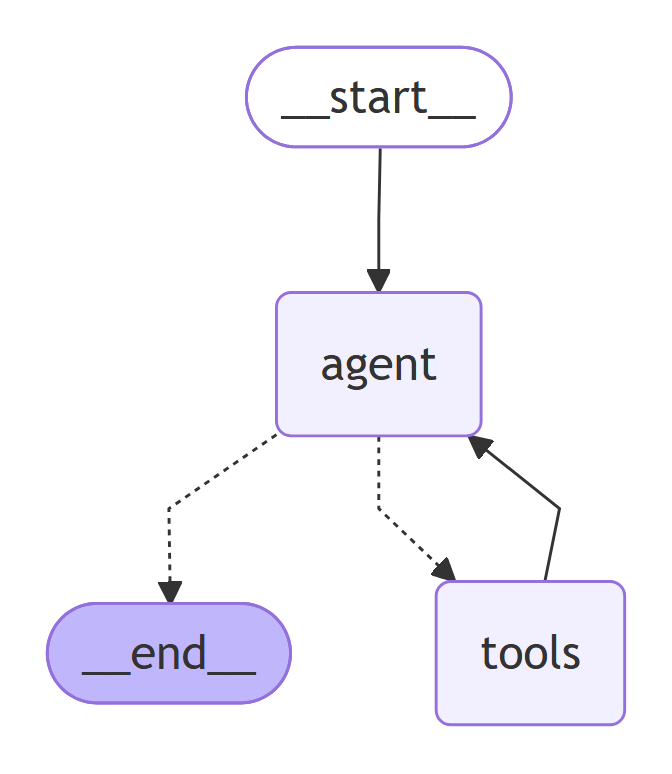

In [25]:
def agent_node(state: MessagesState):
    """Call the LLM with the current message history."""
    response = CorporateChatModel().invoke(state["messages"])
    return {"messages": [response]}

# Build the graph
graph_builder = StateGraph(MessagesState)

# Add nodes
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", ToolNode(tools))

# Add edges
graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges("agent", tools_condition)
graph_builder.add_edge("tools", "agent")

# Compile
graph = graph_builder.compile()

print("Graph compiled with agent and tool nodes")

display(Image(graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.PYPPETEER
)))

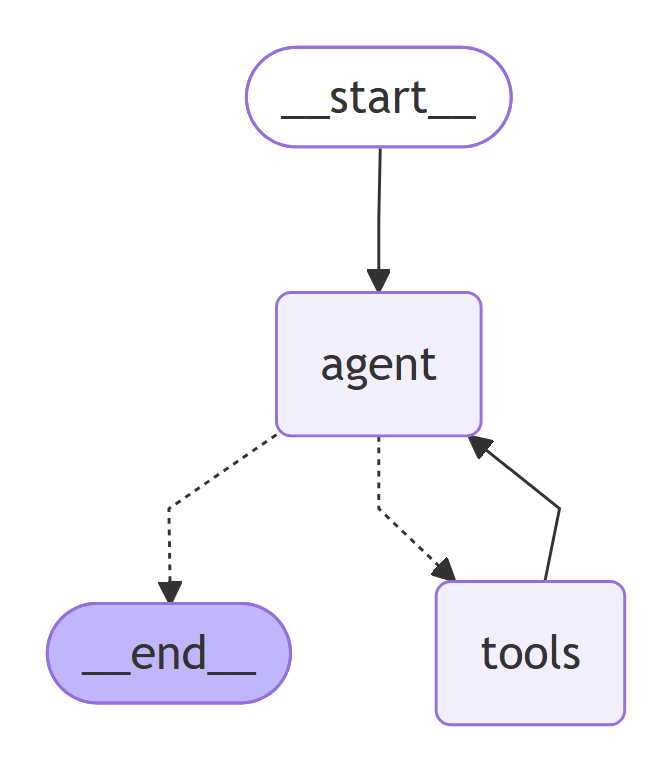

In [26]:
# How Does the LLM Pick the Right Tool from Many?
@tool
def calculate(expression: str) -> str:
    """Evaluate a mathematical expression.
    Use this for any math calculation the user asks for.
    Examples: '2 + 2', '100 * 0.15', '(50 + 30) / 4'
    """
    try:
        result = eval(expression)
        return str(result)
    except Exception as e:
        return f"Error: {e}"

@tool
def lookup_capital(country: str) -> str:
    """Look up the capital city of a country."""
    capitals = {
        "france": "Paris", "germany": "Berlin",
        "japan": "Tokyo", "brazil": "Brasília",
        "india": "New Delhi", "australia": "Canberra"
    }
    return capitals.get(country.lower(), f"Capital not found for {country}")

@tool
def word_count(text: str) -> int:
    """Count the number of words in a piece of text."""
    return len(text.split())

multi_tools = [calculate, lookup_capital, word_count]
#multi_llm = ChatOpenAI(model="gpt-4o-mini").bind_tools(multi_tools)

# def multi_agent(state: MessagesState):
#     return {"messages": [multi_llm.invoke(state["messages"])]}

def agent_node(state: MessagesState):
    """Call the LLM with the current message history."""
    response = CorporateChatModel().invoke(state["messages"])
    return {"messages": [response]}

# Build the graph
graph_builder = StateGraph(MessagesState)

multi_graph = StateGraph(MessagesState)
multi_graph.add_node("agent", agent_node)
multi_graph.add_node("tools", ToolNode(multi_tools))
multi_graph.add_edge(START, "agent")
multi_graph.add_conditional_edges("agent", tools_condition)
multi_graph.add_edge("tools", "agent")
multi_graph = multi_graph.compile()

display(Image(multi_graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.PYPPETEER
)))

In [71]:
# Manual function is our tool.

def temp(message: str):
    print("Tool Called")
    return {f"Current temperature: 22°C"}

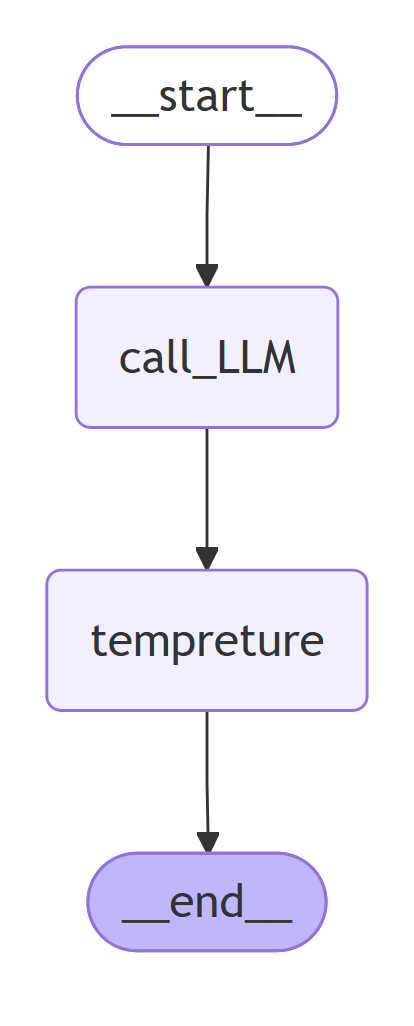

---Node 1---
Tool Called
================================ System Message ================================
Name: System

You are a helpful travel assistant. Answer briefly.
================================ Human Message =================================
Name: Rahul

What is the capital of France?
================================== Ai Message ==================================

Paris.
================================= Tool Message =================================
Name: WeatherTool

Current temperature: 22°C


In [77]:
#State: Define the State of the graph.

from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage

class State(TypedDict):
    graph_state: list[BaseMessage]


#Nodes: Nodes are just python functions.
def call_LLM(state):
    print("---Node 1---")
    model = CorporateChatModel()
    response = model.invoke(state["graph_state"])
    return {"graph_state": state["graph_state"] + [response]}

def tempreture(state):
    print("Tool Called")
    tool_msg = ToolMessage(content="Current temperature: 22°C", tool_call_id="tempreture", name="WeatherTool")
    return {"graph_state": state["graph_state"] + [tool_msg]}

# Build graph
builder = StateGraph(State)
builder.add_node("call_LLM", call_LLM)
builder.add_node("tempreture", tempreture)

builder.add_edge(START, "call_LLM")
builder.add_edge("call_LLM", "tempreture")
builder.add_edge("tempreture", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.PYPPETEER
)))

messages = [SystemMessage(content="You are a helpful travel assistant. Answer briefly.", name="System"),
            HumanMessage(content="What is the capital of France?", name="Rahul")]

result = graph.invoke({"graph_state": messages})
for m in result["graph_state"]:
    m.pretty_print()


# Using Router

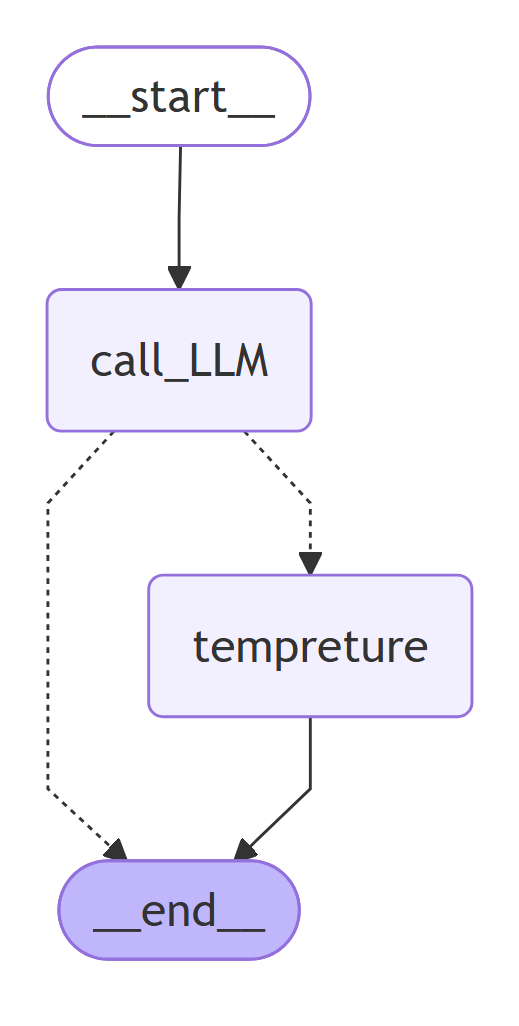

---Node 1---
Tool Called
================================ System Message ================================
Name: System

You are a helpful travel assistant. Answer briefly.
================================ Human Message =================================
Name: Rahul

What is the capital of France?
================================= Tool Message =================================
Name: System

What is the current temperature?
================================== Ai Message ==================================

Paris.
================================= Tool Message =================================
Name: WeatherTool

Current temperature: 22°C


In [75]:
#State: Define the State of the graph.

from typing import Literal
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage

class State(TypedDict):
    graph_state: list[BaseMessage]


#Nodes: Nodes are just python functions.
def call_LLM(state):
    print("---Node 1---")
    model = CorporateChatModel()
    response = model.invoke(state["graph_state"])
    return {"graph_state": state["graph_state"] + [response]}

def tempreture(state):
    print("Tool Called")
    tool_msg = ToolMessage(content="Current temperature: 22°C", tool_call_id="tempreture", name="WeatherTool")
    return {"graph_state": state["graph_state"] + [tool_msg]}

# Only route to the tool node if a ToolMessage is already present in the conversation.
def route_tool(state) -> Literal["tempreture", "__end__"]:
    if any(isinstance(m, ToolMessage) for m in state["graph_state"]):
        return "tempreture"
    return END

# Build graph
builder = StateGraph(State)
builder.add_node("call_LLM", call_LLM)
builder.add_node("tempreture", tempreture)

builder.add_edge(START, "call_LLM")
builder.add_conditional_edges("call_LLM", route_tool)
builder.add_edge("tempreture", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.PYPPETEER
)))

messages = [SystemMessage(content="You are a helpful travel assistant. Answer briefly.", name="System"),
            HumanMessage(content="What is the capital of France?", name="Rahul"),
            ToolMessage(content="What is the current temperature?", tool_call_id="tempreture", name="System")]

result = graph.invoke({"graph_state": messages})
for m in result["graph_state"]:
    m.pretty_print()


#### Q. What Happens When a Tool Fails?
Tools break. APIs time out. Databases go down. Bad inputs slip through. Your agent must handle these bumps without crashing the whole graph.

`ToolNode` has built-in error handling through its `handle_tool_errors` flag. Set it to `True`, and it catches exceptions. Instead of blowing up, it sends the error message back as a `ToolMessage`. The LLM reads that and responds in a helpful way.

Without `handle_tool_errors=True`, that `ValueError` would crash the whole run. With the flag on, the error turns into a message the LLM can read and explain. The model even tells the user why the math failed — far better than a raw stack trace.

```
@tool
def divide(a: float, b: float) -> float:
    """Divide the first number by the second number."""
    if b == 0:
        raise ValueError("Cannot divide by zero!")
    return a / b

error_tools = [divide]
error_llm = ChatOpenAI(model="gpt-4o-mini").bind_tools(error_tools)

def error_agent(state: MessagesState):
    return {"messages": [error_llm.invoke(state["messages"])]}

error_tool_node = ToolNode(error_tools, handle_tool_errors=True)

error_graph = StateGraph(MessagesState)
error_graph.add_node("agent", error_agent)
error_graph.add_node("tools", error_tool_node)
error_graph.add_edge(START, "agent")
error_graph.add_conditional_edges("agent", tools_condition)
error_graph.add_edge("tools", "agent")
error_graph = error_graph.compile()

result = error_graph.invoke(
    {"messages": [HumanMessage(content="What is 10 divided by 0?")]}
)

for msg in result["messages"]:
    print(f"{msg.type}: {msg.content}")
```

## Real-World Example: A Customer Lookup Agent

In [30]:
# ORDERS_DB = {
#     "ORD-001": {"customer": "Alice", "item": "Laptop", "status": "shipped", "total": 1299.99},
#     "ORD-002": {"customer": "Bob", "item": "Headphones", "status": "delivered", "total": 199.99},
#     "ORD-003": {"customer": "Alice", "item": "Mouse", "status": "processing", "total": 49.99},
# }

# INVENTORY_DB = {
#     "Laptop": {"stock": 15, "price": 1299.99},
#     "Headphones": {"stock": 42, "price": 199.99},
#     "Mouse": {"stock": 0, "price": 49.99},
#     "Keyboard": {"stock": 28, "price": 79.99},
# }

# @tool
# def check_order_status(order_id: str) -> str:
#     """Check the status of a customer order by order ID.
#     Order IDs look like 'ORD-001', 'ORD-002', etc.
#     """
#     order = ORDERS_DB.get(order_id.upper())
#     if not order:
#         return f"No order found with ID: {order_id}"
#     return (f"Order {order_id}: {order['item']} for "
#             f"{order['customer']} — Status: {order['status']}, "
#             f"Total: ${order['total']}")

# @tool
# def check_inventory(product_name: str) -> str:
#     """Check if a product is in stock and its price."""
#     product = INVENTORY_DB.get(product_name)
#     if not product:
#         return f"Product '{product_name}' not found in catalog"
#     status = "In stock" if product["stock"] > 0 else "Out of stock"
#     return f"{product_name}: {status} ({product['stock']} units), Price: ${product['price']}"


# cs_tools = [check_order_status, check_inventory]
# cs_llm = ChatOpenAI(model="gpt-4o-mini").bind_tools(cs_tools)

# def cs_agent(state: MessagesState):
#     system_msg = {
#         "role": "system",
#         "content": "You are a helpful customer service agent. "
#                    "Use tools to look up order and inventory info. "
#                    "Be concise and friendly."
#     }
#     messages = [system_msg] + state["messages"]
#     return {"messages": [cs_llm.invoke(messages)]}

# cs_graph = StateGraph(MessagesState)
# cs_graph.add_node("agent", cs_agent)
# cs_graph.add_node("tools", ToolNode(cs_tools))
# cs_graph.add_edge(START, "agent")
# cs_graph.add_conditional_edges("agent", tools_condition)
# cs_graph.add_edge("tools", "agent")
# cs_graph = cs_graph.compile()

# result = cs_graph.invoke(
#     {"messages": [HumanMessage(content="Check order ORD-001 please")]}
# )
# print("Q: Check order ORD-001 please")
# print(f"A: {result['messages'][-1].content}\n")

# result = cs_graph.invoke(
#     {"messages": [HumanMessage(content="Is the Mouse in stock?")]}
# )
# print("Q: Is the Mouse in stock?")
# print(f"A: {result['messages'][-1].content}")


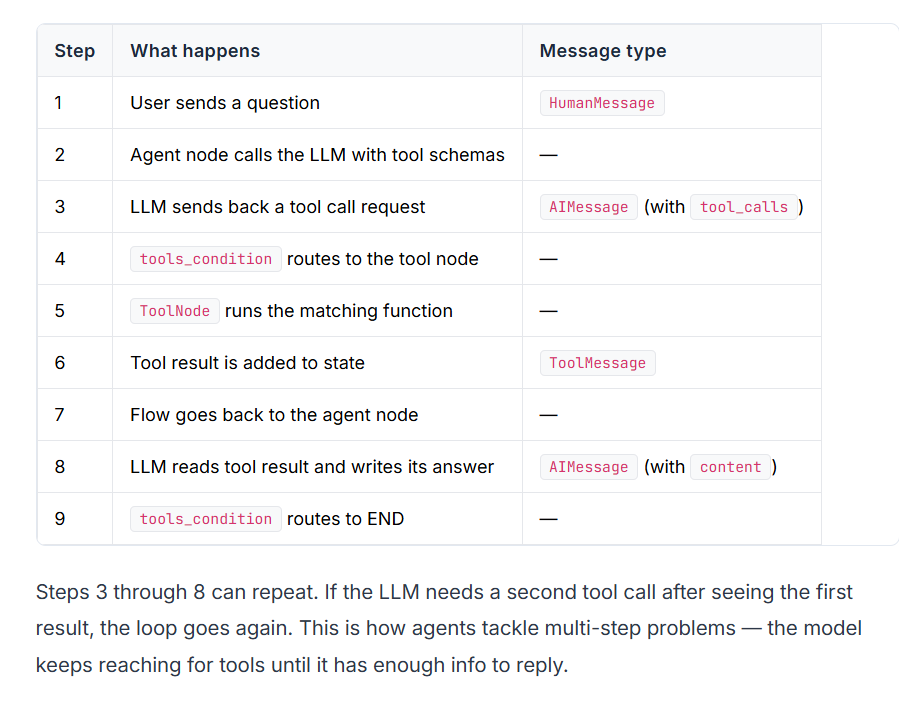

#
Step| 	            |What happens|  	|Message type|
1	User sends a question	HumanMessage
2	Agent node calls the LLM with tool schemas	—
3	LLM sends back a tool call request	AIMessage (with tool_calls)
4	tools_condition routes to the tool node	—
5	ToolNode runs the matching function	—
6	Tool result is added to state	ToolMessage
7	Flow goes back to the agent node	—
8	LLM reads tool result and writes its answer	AIMessage (with content)
9	tools_condition routes to END	—

### Summary
Tool calling is what turns an LLM that thinks into an agent that acts. Here’s what you learned:

* `@tool` decorator wraps any Python function so the LLM can find and call it
* `.bind_tools()` tells the chat model which tools are available and what they expect
* `ToolNode` from `langgraph.prebuilt` runs tools when the LLM asks for them
* `tools_condition` steers the graph based on whether the LLM made a tool call
* **Error handling** via `handle_tool_errors=True` stops tool failures from crashing your graph
* **Multiple tools** work side by side — the LLM picks the right one by reading docstrings

Q. Does LangGraph tool calling work with open-source models?
It does, but results vary by model. Models tuned for function calling (Llama 3.1+, Mistral, Command R+) work well with .bind_tools(). Smaller or older ones may not send back clean tool calls. Check your model’s docs for function calling support before you start.

Q. How do I cap the number of tool-calling loops?
Pass a recursion limit in the config: graph.invoke(inputs, config={"recursion_limit": 10}). The default cap is 25. If the agent goes past it, LangGraph raises a GraphRecursionError. Keep the limit sensible — if an agent needs 20+ tool calls to answer one question, the design likely needs a rethink.
